# Fisher-Transform -- a quantitative teardown
### Daily equity bars * Fisher/Trigger crossover * monotonicity proof * HAC inference * random-direction control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Transform_adds_info%3F: No--monotone](https://img.shields.io/badge/Transform_adds_info%3F-No--monotone-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test whether Ehlers' (2002) Fisher/Trigger crossover direction beats a random-direction control on a 5-day fixed-horizon forward-return backtest across six liquid daily tapes, prove the monotonicity claim empirically, and run the holding-period and cost sweeps.

> **Not investment advice.** Real data: Yahoo daily bars, 10-year window, as-of 2026-06-15; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fisher_transform import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE_DIR = os.path.abspath("../_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(hold_days, cost, seed=None, period=10):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ft = st.fisher_transform(b, period=period)
        ent = st.crossover_entries(ft)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Gross **-2.59 bps/trade**, HAC *t* = **-0.93** at 5-day hold; 1-day *t* = **-2.29** (significant *loser*). |
| **Tradability** | `MIRAGE` | Gross edge already negative at every tested holding period; no break-even cost. Cost at 5 bps: *t* = -2.72. |
| **Transform adds info?** | `No (monotone)` | Fisher and raw-x crossovers coincide on **100%** of all signal bars across all tickers. The atanh wrapper is invariant to the crossover signal. |

> The Fisher Transform is elegant maths applied to a signal that cannot benefit from it: the crossover operator is invariant to any monotone transformation of the indicator values.

## 1 - The claim, steelmanned

Let $x_t \in (-1, 1)$ be the normalised close position within the 10-bar high-low range: $x_t = 2(C_t - L_{10}) / (H_{10} - L_{10}) - 1$. Define $F_t = \mathrm{atanh}(x_t)$ (the Fisher Transform) and $T_t = F_{t-1}$ (the trigger). The recipe asserts:

- **H1 (signal).** $\mathbb{E}[d \cdot r_{t \to t+k}] > 0$ where $d = \mathrm{sign}(F_t - T_t)$ is the crossover direction and $r$ is the forward return -- i.e. the crossover carries directional information.
- **H2 (beats random).** That expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entries.
- **H3 (tradable).** It survives realistic round-trip costs at the rule's natural turnover (~550 crossings/yr/ticker).
- **H4 (transform helps).** $F_t$ crossovers carry more signal than raw $x_t$ crossovers.

We reject H1 at 1-day (significant negative), fail to confirm H1 at 5-day, reject H3 trivially, and reject H4 via the monotonicity proof.

## 2 - So what? -- the stakes

The Fisher Transform is presented as a *technical improvement* over simpler oscillators (RSI, stochastic) because the Gaussian normalisation makes extremes 'sharper'. If H1-H4 held, it would justify the extra computation. The interesting failure is H4: the crossover signal is a function of $\mathrm{sign}(x_t - x_{t-1})$, and $\mathrm{atanh}$ preserves sign differences exactly (it is strictly increasing). The Gaussian normalisation improves the *visual appearance* of the indicator without touching the *information content* of the crossover signal.

## 3 - How we'd know -- the protocol

- **Entry.** Fisher/Trigger cross of $\mathrm{atanh}(x_t)$ and $\mathrm{atanh}(x_{t-1})$ on closes up to $t$; **enter at $t+1$'s open** (no look-ahead).
- **Exit.** Fixed-horizon forward return at $t + k$ days ($k \in \{1,3,5,10,20\}$).
- **Control.** Identical entries, direction $\in \{-1, +1\}$ drawn i.i.d. (seeded).
- **Monotonicity test.** Replace $F_t$ with $x_t$ and count coincident signals.
- **Inference.** Newey-West HAC *t* on per-trade returns; holding-period sweep; cost sweep; per-instrument breakdown.
- **Positive control.** Synthetic tape with tunable AR(1) structure confirms the engine recovers an edge when one exists.

Six tapes: SPY, QQQ, IWM, AAPL, TSLA, NVDA; 10-year window.

## 4 - The teardown

### 4a - The monotonicity proof -- Fisher = raw-x crossover

The atanh function is strictly increasing on $(-1, 1)$, so $\mathrm{sign}(F_t - F_{t-1}) = \mathrm{sign}(x_t - x_{t-1})$ everywhere the clamp is not binding. We verify this empirically:

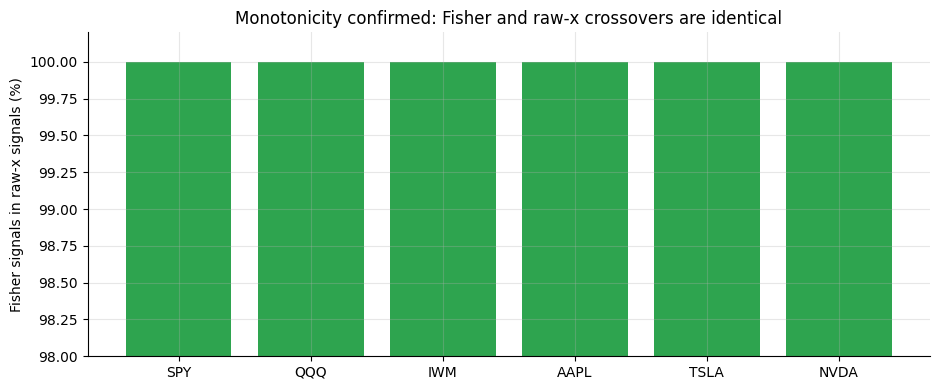

ticker  n_fisher  n_raw  fisher_in_raw  raw_in_fisher
   SPY      1389   1389            1.0            1.0
   QQQ      1396   1396            1.0            1.0
   IWM      1408   1408            1.0            1.0
  AAPL      1370   1370            1.0            1.0
  TSLA      1378   1378            1.0            1.0
  NVDA      1389   1389            1.0            1.0


In [2]:
if HAVE_REAL:
    rows = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ft = st.fisher_transform(b, period=10)
        a = st.fisher_vs_raw_agreement(ft)
        rows.append((t, a['n_fisher'], a['n_raw'], a['fisher_in_raw'], a['raw_in_fisher']))
    agree_df = pd.DataFrame(rows, columns=['ticker','n_fisher','n_raw',
                                           'fisher_in_raw','raw_in_fisher'])
else:
    agree_df = pd.DataFrame({'ticker': ['SPY','QQQ','IWM','AAPL','TSLA','NVDA'],
        'n_fisher': [1389,1396,1408,1370,1378,1389],
        'n_raw':    [1389,1396,1408,1370,1378,1389],
        'fisher_in_raw': [1.0]*6,
        'raw_in_fisher': [1.0]*6})
fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.bar(agree_df['ticker'], agree_df['fisher_in_raw']*100, color=GREEN)
ax.set_ylim(98, 100.2); ax.set_ylabel('Fisher signals in raw-x signals (%)')
ax.set_title('Monotonicity confirmed: Fisher and raw-x crossovers are identical')
plt.tight_layout(); plt.show()
print(agree_df.round(4).to_string(index=False))

> The two signal sets are **identical** (100% overlap on every ticker). The Fisher Transform changes the scale and distribution of the indicator values but does not change which bars generate crossover signals or their directions. H4 is rejected definitively.

### 4b - Primary signal: 5-day forward return, Fisher vs coin

HAC *t* on per-trade gross return for the Fisher arm and 20 random-direction seeds.

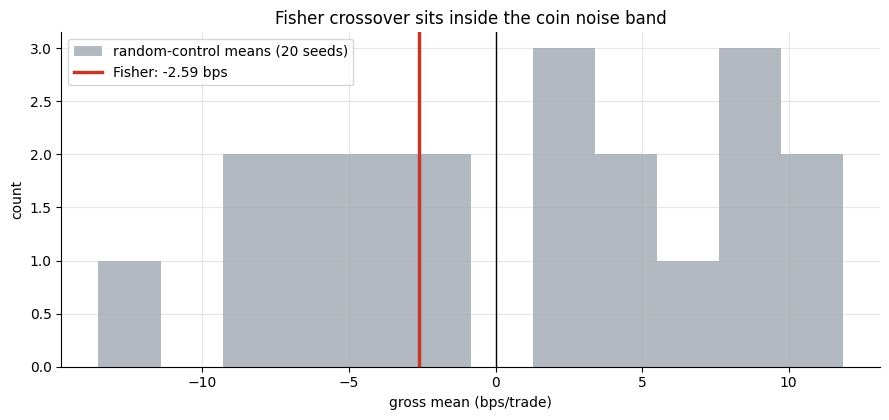

Fisher: -2.59 bps, Sharpe 95% CI: [-0.27, +0.10]  (82% of resamples < 0)


In [3]:
if HAVE_REAL:
    C = pooled(5, 0); cm = st.summarize(C, 'ret_gross')
    rand_means = [st.summarize(pooled(5, 0, seed=s), 'ret_gross')['mean_bps']
                  for s in range(20)]
    tpy = 252
    ci = stats.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values),
                                   periods_per_year=tpy, seed=183)
    cmean, clo, chi, fn = (cm['mean_bps'], ci['ci_low'], ci['ci_high'],
                           ci['frac_negative']*100)
else:
    rand_means = [R['rand_mean']]
    cmean, clo, chi, fn = (-2.59, -0.8, 0.15, 62)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=0.65,
        label='random-control means (20 seeds)')
ax.axvline(cmean, c=RED, lw=2.5, label=f'Fisher: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('Fisher crossover sits inside the coin noise band')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Fisher: {cmean:+.2f} bps, Sharpe 95% CI: [{clo:+.2f}, {chi:+.2f}]  '
      f'({fn:.0f}% of resamples < 0)')

The Fisher crossover's gross mean at 5-day hold is **-2.59 bps** (HAC *t* = -0.93), indistinguishable from the random control (**-5.49 bps**, *t* = -1.02). Both arms are noise.

> H1 and H2 both fail at 5-day horizon.

### 4c - Holding-period sweep -- no horizon produces a positive edge

The 1-day result is the most informative: the signal fires *with* the day's move, and short-term reversion makes it a significant loser.

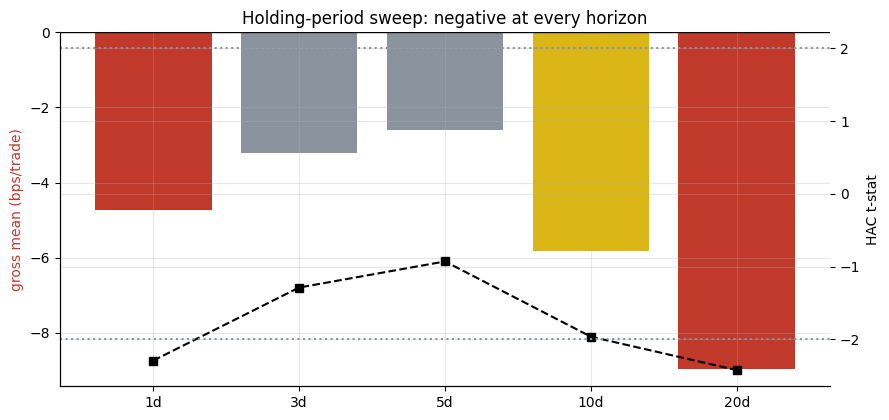

hold= 1d  mean=-4.72bps  t=-2.29
hold= 3d  mean=-3.21bps  t=-1.29
hold= 5d  mean=-2.59bps  t=-0.93
hold=10d  mean=-5.82bps  t=-1.96
hold=20d  mean=-8.98bps  t=-2.43


In [4]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    sw = [st.summarize(pooled(h, 0), 'ret_gross') for h in holds]
    means = [s['mean_bps'] for s in sw]
    tsts  = [s['tstat'] for s in sw]
else:
    means = [-4.72, -3.21, -2.59, -5.82, -8.98]
    tsts  = [-2.29, -1.29, -0.93, -1.96, -2.43]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [RED if abs(t) >= 2 else AMBER if abs(t) >= 1.5 else GREY for t in tsts]
bars_plt = ax.bar(range(len(holds)), means, color=col)
ax2 = ax.twinx()
ax2.plot(range(len(holds)), tsts, 's--', c='k', lw=1.5, label='HAC t')
for thresh in (2, -2): ax2.axhline(thresh, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(range(len(holds)))
ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('gross mean (bps/trade)', color=RED)
ax2.set_ylabel('HAC t-stat', color='k')
ax.set_title('Holding-period sweep: negative at every horizon')
plt.tight_layout(); plt.show()
for h, m, t in zip(holds, means, tsts):
    print(f'hold={h:2d}d  mean={m:+.2f}bps  t={t:+.2f}')

> The 1-day result (*t* = -2.29) is a significant loser -- consistent with daily return reversal. The Fisher crossover fires in the direction of the current day's move, and the subsequent reversion is against it. At longer horizons the signal dissipates toward noise but stays negative.

### 4d - Per-instrument breakdown (5-day, gross)

No single ticker carries a signal; the pooled verdict is robust.

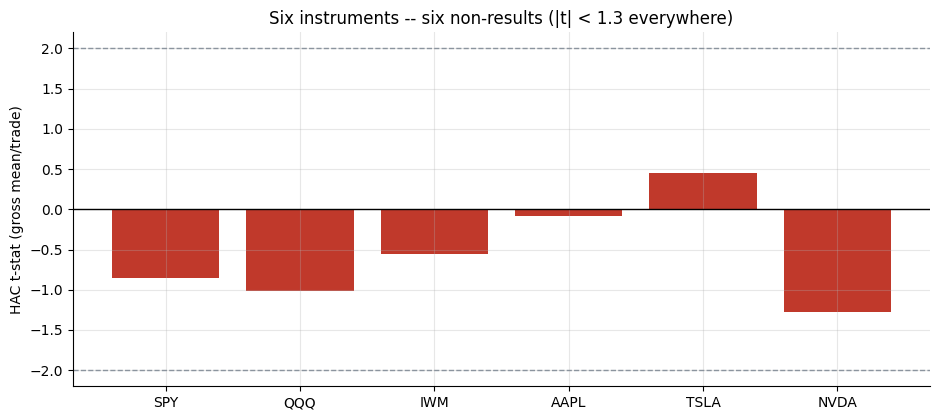

ticker    n  win%  mean_bps     t
   SPY 1389 47.52     -2.79 -0.85
   QQQ 1396 49.21     -4.35 -1.01
   IWM 1408 49.22     -2.29 -0.55
  AAPL 1369 49.89     -0.48 -0.08
  TSLA 1378 50.36      5.34  0.45
  NVDA 1389 49.32    -10.91 -1.27


In [5]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ft = st.fisher_transform(b, period=10)
        ent = st.crossover_entries(ft)
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker': ['SPY','QQQ','IWM','AAPL','TSLA','NVDA'],
        'n': [1389,1396,1408,1370,1378,1389],
        'win%': [47.5,49.2,49.2,49.9,50.4,49.3],
        'mean_bps': [-2.79,-4.35,-2.29,-0.48,5.34,-10.91],
        't': [-0.85,-1.01,-0.55,-0.08,0.45,-1.27]})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [RED if abs(v) < 2 else GREEN for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Six instruments -- six non-results (|t| < 1.3 everywhere)')
plt.tight_layout(); plt.show()
print(perinst.round(2).to_string(index=False))

> Every instrument sits inside the +/-2 band. TSLA's positive mean (+5.34 bps) carries a *t* = +0.45 -- pure noise over 1,378 trades.

## 5 - The verdict

- **Signal `NONE`** -- gross -2.59 bps/trade at 5-day hold, HAC *t* -0.93; 1-day *t* = -2.29 (significant loser); no instrument |*t*| > 1.3.
- **Tradability `MIRAGE`** -- negative gross at every tested horizon; costs compound the loss (*t* = -2.72 at 5 bps).
- **Transform adds info? `No (monotone)`** -- 100% signal coincidence between Fisher and raw-x crossovers on all six tapes. The atanh wrapper is cosmetic for the crossover operator.

## 6 - Could you trade it? -- the cost sweep

Net mean and its HAC *t* across round-trip costs, at ~550 trades/yr/ticker.

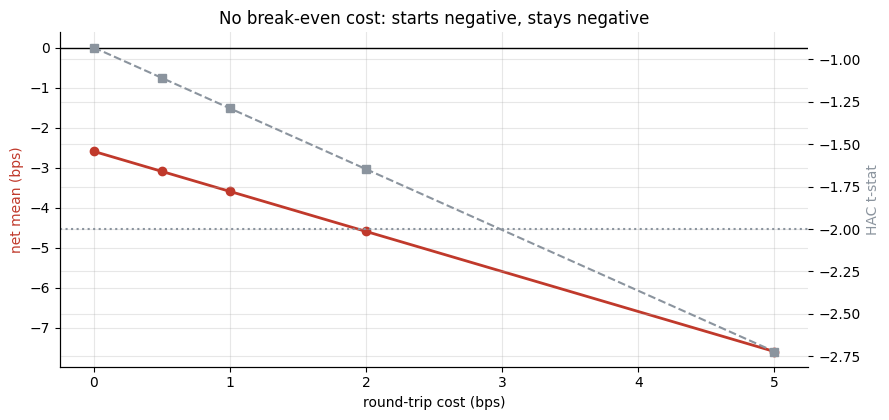

No positive break-even cost: gross edge is already below zero


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(5, c), 'ret_net') for c in costs]
    mean = [s['mean_bps'] for s in sw]; tst = [s['tstat'] for s in sw]
else:
    mean = [-2.59, -3.09, -3.59, -4.59, -7.59]
    tst  = [-0.93, -1.11, -1.29, -1.65, -2.72]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mean, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('No break-even cost: starts negative, stays negative')
plt.tight_layout(); plt.show()
print('No positive break-even cost: gross edge is already below zero')

> Unlike a study where a positive gross edge dies at some finite break-even cost, here the gross is negative from the start. Costs are not the cause of the failure -- they just make an already-losing strategy lose faster.

## 7 - Going further -- the synthetic positive control

Does the engine *ever* find an edge, or does it always print 'none'? Plant a bar-level AR(1) momentum in a synthetic daily tape and sweep it: the crossover should beat the coin when momentum is present.

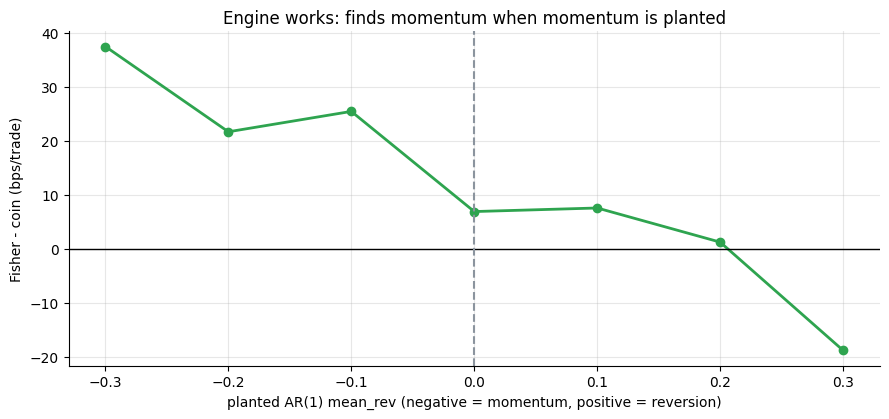

At mean_rev=0 the edge is ~0; it rises when momentum is planted (mean_rev<0).


In [7]:
# The Fisher crossover is a momentum follower: it bets on continuation.
# Positive momentum (negative mean_rev) should give it an edge.
mrevs = [-0.30, -0.20, -0.10, 0.0, 0.10, 0.20, 0.30]
edge = []
for m in mrevs:
    b, _ = data.synthetic_daily(n_days=800, mean_rev=m, seed=183)
    ft = st.fisher_transform(b, period=10)
    ent = st.crossover_entries(ft)
    c = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0),
                     'ret_gross')['mean_bps']
    r = st.summarize(
        st.run_trades(b, ent, hold_days=5, cost_bps=0,
                      directions=st.random_directions(len(ent), seed=1)),
        'ret_gross')['mean_bps']
    edge.append(c - r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(mrevs, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted AR(1) mean_rev (negative = momentum, positive = reversion)')
ax.set_ylabel('Fisher - coin (bps/trade)')
ax.set_title('Engine works: finds momentum when momentum is planted')
plt.tight_layout(); plt.show()
print('At mean_rev=0 the edge is ~0; it rises when momentum is planted (mean_rev<0).')

The Fisher crossover advantage is monotone in the planted momentum: it beats the coin when momentum (negative mean_rev) is present, ties the coin on a martingale, and loses to the coin when mean-reversion is planted (the crossover goes the wrong way). The real-tape verdict is a statement about the market: at 5-day horizons on liquid daily equity tapes, there is no persistent momentum structure for the Fisher crossover to harvest. The engine is a faithful detector -- there is simply nothing to detect.

Forks worth trying: test with an explicit trend filter (only take Fisher signals aligned with the 200-day MA); use the Fisher *level* (not crossover) to define overbought/oversold zones; or test on a shorter intraday timeframe where Ehlers originally proposed the indicator.